In [17]:
import xarray as xr
from pathlib import Path

data_dir = Path("/data0/balaji24/data/snotel")

all_sites = set()

for zarr_path in data_dir.glob("*_SNOTEL_daily_data.zarr"):
    ds = xr.open_zarr(zarr_path)
    # use `site` not `station`
    sites = ds["site"].values.tolist()
    all_sites.update(sites)

expected_sites = sorted(all_sites)
len(expected_sites), expected_sites

(9,
 ['1080:WA:SNTL',
  '1319:WA:SNTL',
  '711:WA:SNTL',
  '817:WA:SNTL',
  '975:WA:SNTL',
  '990:WA:SNTL',
  '991:WA:SNTL',
  '998:WA:SNTL',
  '999:WA:SNTL'])

In [18]:
site_to_name = {}

for zarr_path in data_dir.glob("*_SNOTEL_daily_data.zarr"):
    ds = xr.open_zarr(zarr_path)
    sites = ds["site"].values.tolist()
    names = ds["site_name"].values.tolist()
    for s, n in zip(sites, names):
        site_to_name.setdefault(s, n)

len(site_to_name), list(site_to_name.items())[:5]

(9,
 [('711:WA:SNTL', 'Rainy Pass'),
  ('817:WA:SNTL', 'Thunder Basin'),
  ('975:WA:SNTL', 'Swamp Creek'),
  ('990:WA:SNTL', 'Beaver Pass'),
  ('991:WA:SNTL', 'Hozomeen Camp')])

In [19]:
import pandas as pd
import xarray as xr
from pathlib import Path

data_dir = Path("/data0/balaji24/data/snotel")

rows = []

for zarr_path in sorted(data_dir.glob("*_SNOTEL_daily_data.zarr")):
    fname = zarr_path.name
    start_date = fname.split("_")[0]   # '2014-01-01'
    year = start_date[:4]
    month = start_date[5:7]

    ds = xr.open_zarr(zarr_path)
    present = set(ds["site"].values.tolist())

    missing = set(expected_sites) - present

    rows.append({
        "year": int(year),
        "month": int(month),
        "present_count": len(present),
        "missing_count": len(missing),
        "missing_sites": sorted(list(missing)),
    })

df = pd.DataFrame(rows)
df.sort_values(["year", "month"], inplace=True)
df

,year,month,present_count,missing_count,missing_sites
0,2014,1,7,2,"[1319:WA:SNTL, 998:WA:SNTL]"
1,2014,1,7,2,"[1319:WA:SNTL, 998:WA:SNTL]"
2,2014,2,7,2,"[1319:WA:SNTL, 998:WA:SNTL]"
3,2014,3,7,2,"[1319:WA:SNTL, 998:WA:SNTL]"
4,2014,4,7,2,"[1319:WA:SNTL, 998:WA:SNTL]"
...,...,...,...,...,...
91,2023,5,6,3,"[1080:WA:SNTL, 1319:WA:SNTL, 998:WA:SNTL]"
92,2023,6,6,3,"[1080:WA:SNTL, 1319:WA:SNTL, 998:WA:SNTL]"
93,2023,7,6,3,"[1080:WA:SNTL, 1319:WA:SNTL, 998:WA:SNTL]"
94,2023,8,6,3,"[1080:WA:SNTL, 1319:WA:SNTL, 998:WA:SNTL]"


In [20]:
import os, re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

BASE = Path("/data0/balaji24/data")
P_HRRR_DIR = BASE / "weather_data"

def smart_deaccumulate_hrrr_tp(da, time_dim="time", reset_drop_threshold_mm=0.1):
    """
    De-accumulate HRRR total precipitation 'tp' with frequent resets.

    Logic:
    - 'tp' is cumulative within each forecast cycle, then jumps back to ~0 at cycle boundaries.
    - We detect those resets from the time derivative and prevent diffing *across* them.
    - Inside each segment (between resets) we do forward diff and clip negatives to 0.

    Assumes:
      - units are mm or kg m**-2 (≈ mm)
      - dims: (time, y, x) or similar with a 'time' dimension
    """
    # ---- 0. Make sure time is sorted & unique ----
    da = ensure_time_sorted_unique(da)

    if time_dim not in da.dims:
        raise ValueError(f"{time_dim} not in dims: {da.dims}")

    spatial_dims = [d for d in da.dims if d != time_dim]

    # ---- 1. Work in mm (convert meters if needed) ----
    units = str(da.attrs.get("units", "")).lower()
    if units in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"
    elif "kg m" in units and "-2" in units:
        # 1 kg m^-2 ≈ 1 mm
        da.attrs["units"] = "mm"

    # ---- 2. Detect resets from negative jumps in time derivative ----
    diff = da.diff(time_dim, label="upper")  # same dims minus one in time

    # where does tp drop sharply? (reset points)
    if spatial_dims:
        # any grid cell with a big negative drop → treat as cycle reset
        reset_any = (diff < -reset_drop_threshold_mm).any(dim=spatial_dims)
    else:
        reset_any = (diff < -reset_drop_threshold_mm)

    # Build a segment ID per time step:
    # seg_id = 0 for first block, 1 for after first reset, etc.
    seg_ids = np.zeros(da.sizes[time_dim], dtype="int32")
    # align reset_any (length N-1) to time index [1..N-1]
    seg_ids[1:] = np.cumsum(reset_any.values.astype("int32"))
    seg = xr.DataArray(
        seg_ids,
        coords={time_dim: da[time_dim]},
        dims=(time_dim,),
        name="forecast_segment",
    )

    # ---- 3. De-accumulate *within* each segment only ----
    def _deacc_block(block):
        """Diff inside one segment and prepend a 0 at the start."""
        bdiff = block.diff(time_dim, label="upper")
        bdiff = bdiff.where(bdiff >= 0, 0)  # remove small negatives/resets
        # prepend zero at first timestep of this segment
        zero = block.isel({time_dim: slice(0, 1)}) * 0
        out = xr.concat([zero, bdiff], dim=time_dim)
        return out

    inc = da.groupby(seg).map(_deacc_block)
    inc.attrs["units"] = "mm"
    return inc

[SNOTEL] Found 97 monthly zarrs


/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


[SNOTEL] Using variable: PRECIPITATION, dims=('time', 'site'), shape=(11654, 9)
[SNOTEL] Raw units='', max=14.2
[SNOTEL] Converting to mm (assumed inches or missing/low units)
[SNOTEL] Stations inside Skagit: 7/9
[SNOTEL] annual_site dims=('year', 'site'), years=[2014 2015 2016 2017 2018 2019 2020]


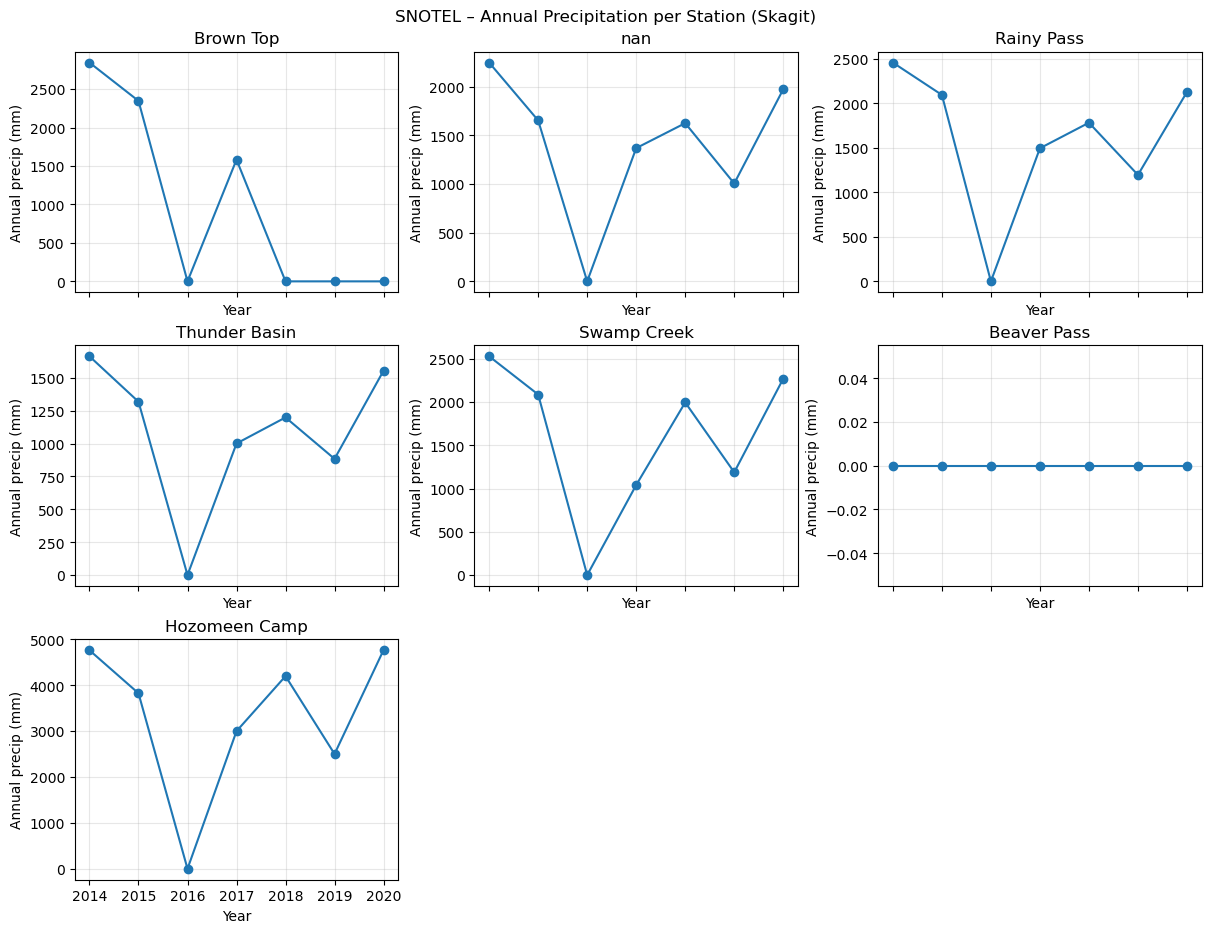

In [21]:
import os, json
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
P_SNOTEL_DIR = BASE / "snotel"
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2020

# ---------------- Helpers ----------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = da["time"].values
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def _load_boundary_geom():
    from shapely.geometry import shape, Polygon, LinearRing
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)

    if isinstance(obj, dict) and obj.get("type") == "FeatureCollection":
        return shape(obj["features"][0]["geometry"])
    if isinstance(obj, dict) and obj.get("type") == "Feature":
        return shape(obj["geometry"])
    if isinstance(obj, dict) and {"lon", "lat"} <= obj.keys():
        pts = list(zip(obj["lon"], obj["lat"]))
        if pts[0] != pts[-1]:
            pts.append(pts[0])
        return Polygon(LinearRing(pts))
    raise ValueError("Boundary format not recognized.")

# ---------------- SNOTEL per-station annual totals ----------------
if not P_SNOTEL_DIR.exists():
    raise SystemExit(f"SNOTEL dir not found: {P_SNOTEL_DIR}")

snotel_months = sorted(P_SNOTEL_DIR.glob("**/*.zarr"))
if not snotel_months:
    raise SystemExit("No SNOTEL zarrs found")

print(f"[SNOTEL] Found {len(snotel_months)} monthly zarrs")

# 1) Load all months
dss = xr.concat(
    [safe_open_zarr(p) for p in snotel_months],
    dim="time",
    join="outer",
    coords="minimal",
    compat="override",
)

# 2) Choose precip variable (same as your working code)
vS = next(
    (
        v
        for v in [
            "PRECIPITATION",
            "ppt",
            "prcp",
            "ACCUMULATED PRECIPITATION",
            "accum_precip",
        ]
        if v in dss
    ),
    None,
)

if vS is None:
    raise SystemExit("[SNOTEL] No precip variable found")

da = dss[vS]
print(f"[SNOTEL] Using variable: {vS}, dims={da.dims}, shape={da.shape}")

# 3) Units / scale handling – EXACTLY your “correct scale” logic
units = str(da.attrs.get("units", "")).lower()
max_val = float(da.max(skipna=True))
print(f"[SNOTEL] Raw units='{units}', max={max_val}")

if (not units) or (units in {"inch", "in", "inches"}) or (max_val <= 10.0):
    da = da * 25.4
    da.attrs["units"] = "mm"
    print("[SNOTEL] Converting to mm (assumed inches or missing/low units)")
else:
    if not units:
        da.attrs["units"] = "mm"

# 4) Restrict to Skagit stations (lat/lon in basin), but KEEP site dimension
site_dim = "site" if "site" in da.dims else None
if site_dim and ("lat" in dss.coords) and ("lon" in dss.coords):
    import shapely.geometry as sgeom

    geom = _load_boundary_geom()
    lats = dss["lat"].values
    lons = dss["lon"].values

    inside = []
    for i in range(len(lats)):
        pt = sgeom.Point(float(lons[i]), float(lats[i]))
        inside.append(geom.contains(pt))

    inside = np.array(inside, dtype=bool)
    print(f"[SNOTEL] Stations inside Skagit: {inside.sum()}/{inside.size}")
    if inside.any():
        da = da.isel({site_dim: np.where(inside)[0]})

# 5) Clean time + restrict to study years (boolean mask to avoid the KeyError)
da = ensure_time_sorted_unique(da)
if "time" in da.dims:
    t = da["time"]
    mask = (t >= np.datetime64(f"{YEAR_MIN}-01-01")) & (t <= np.datetime64(f"{YEAR_MAX}-12-31"))
    da = da.sel(time=mask)

# 6) Daily totals (if sub-daily, this aggregates; if daily, it's a no-op sum)
daily = da.resample(time="1D").sum()

# 7) Annual totals per station
annual_site = daily.groupby("time.year").sum("time")
if "time.year" in annual_site.coords:
    annual_site = annual_site.rename({"time.year": "year"})
years = annual_site["year"].values
print(f"[SNOTEL] annual_site dims={annual_site.dims}, years={years}")

# 8) Station names
if site_dim and "site_name" in dss:
    names = dss["site_name"].values
elif site_dim and "stationTriplet" in dss:
    names = dss["stationTriplet"].values
else:
    if site_dim:
        names = [f"site {i}" for i in range(annual_site.sizes[site_dim])]
    else:
        names = ["SNOTEL"]

# 9) Plot per-station
if site_dim:
    n_sites = annual_site.sizes[site_dim]
    ncols = 3
    nrows = int(np.ceil(n_sites / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4 * ncols, 3 * nrows),
        sharex=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for i in range(n_sites):
        ax = axes[i]
        series_i = annual_site.isel({site_dim: i})

        ax.plot(years, series_i.values, marker="o")
        ax.set_title(str(names[i]))
        ax.set_xlabel("Year")
        ax.set_ylabel("Annual precip (mm)")
        ax.grid(alpha=0.3)

    for j in range(n_sites, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("SNOTEL – Annual Precipitation per Station (Skagit)", y=1.02)
    plt.show()
else:
    plt.figure(figsize=(6, 4))
    plt.plot(years, annual_site.values, marker="o")
    plt.xlabel("Year")
    plt.ylabel("Annual precip (mm)")
    plt.title("SNOTEL – Annual Precipitation (single series)")
    plt.grid(alpha=0.3)
    plt.show()

In [22]:
!pip install intake intake-xarray requests aiohttp

In [23]:
!pip install s3fs

In [24]:
# ===============================================================
# ONE-CELL SCRIPT: Download CONUS404 DRB precip (2015) from HyTEST
# Saves: conus404_drb_precip_2015.nc (incremental precip)
# ===============================================================

# --- Install deps (safe to re-run) ---
import sys
!{sys.executable} -m pip install -q intake intake-xarray xarray zarr fsspec s3fs pandas

# --- Imports ---
import intake
import xarray as xr
import pandas as pd
from pathlib import Path

print("✓ Imports & installations complete")

# --- 1. Open HyTEST intake catalog ---
url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
cat = intake.open_catalog(url)
print("✓ Catalog opened")

# --- 2. Access DRB subcatalog ---
conus_subcat = cat["conus404-drb-eval-tutorial-catalog"]
print("✓ Subcatalog loaded")

# --- 3. Load DRB CONUS404 dataset from OSN ---
ds = conus_subcat["conus404-drb-OSN"].to_dask()
print("✓ Loaded CONUS404 DRB dataset from OSN")

# --- 4. Extract 2015 cumulative precipitation ---
var_name = "PREC_ACC_NC"
precip_2015 = ds[var_name].sel(time=slice("2015-01-01", "2015-12-31"))
print("✓ Extracted PREC_ACC_NC for 2015")

# --- 5. Convert cumulative → incremental precipitation ---
precip_inc = (
    precip_2015
    .sortby("time")
    .diff("time", label="lower")
    .where(lambda x: x >= 0)
)
print("✓ Converted to incremental precipitation")

# --- 6. Save the result ---
outfile = Path("conus404_drb_precip_2015.nc")
precip_inc.to_dataset(name="PRECIP_INC").to_netcdf(outfile)
print(f"✓ Saved reference file: {outfile.resolve()}")

# --- 7. Final confirmation ---
xr.open_dataset(outfile)

✓ Imports & installations complete
✓ Catalog opened
✓ Subcatalog loaded
✓ Loaded CONUS404 DRB dataset from OSN
✓ Extracted PREC_ACC_NC for 2015
✓ Converted to incremental precipitation


PermissionError: [Errno 13] Permission denied: '/home/balaji24/skagit-met/analysis/conus404_drb_precip_2015.nc'

✓ Loaded conus404-daily-osn
✓ Selected PREC_ACC_NC for 2014–2020
✓ Loaded Skagit boundary
✓ Built Skagit mask
✓ Computed basin-mean daily precip
Annual totals (mm):
2014: 2650.3 mm
2015: 2102.4 mm
2016: 2415.3 mm
2017: 2318.6 mm
2018: 2312.8 mm
2019: 1587.5 mm
2020: 2605.2 mm


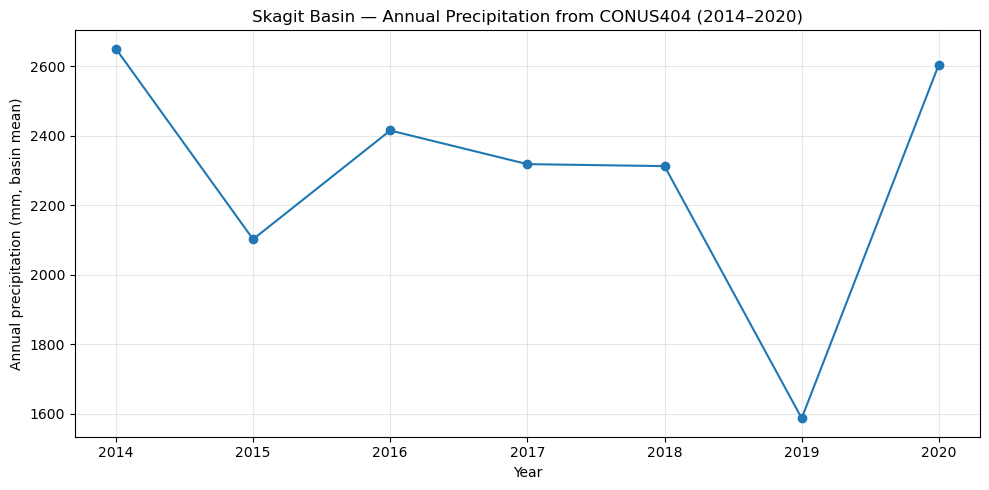

In [14]:
# ================================================
# Skagit Basin — Annual Precipitation from CONUS404
# (2014–2020, using PREC_ACC_NC)
# ================================================

import sys
!{sys.executable} -m pip install -q intake intake-xarray xarray zarr fsspec s3fs geopandas shapely matplotlib

import intake
import xarray as xr
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt

# 1) Open CONUS404 daily dataset
url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
cat = intake.open_catalog(url)
ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
print("✓ Loaded conus404-daily-osn")

# 2) Select precip + time range
var = "PREC_ACC_NC"
if var not in ds.data_vars:
    raise KeyError(f"{var} not found in dataset")

precip = ds[var].sel(time=slice("2014-01-01", "2020-12-31"))
print("✓ Selected PREC_ACC_NC for 2014–2020")

# 3) Load Skagit boundary and build mask (lat/lon are already 2D)
skagit_geo = "../data/GIS/SkagitBoundary.json"  # adjust path if needed
gdf = gpd.read_file(skagit_geo)
geom = gdf.geometry.iloc[0]
print("✓ Loaded Skagit boundary")

lat = ds["lat"]
lon = ds["lon"]
mask_np = shapely.contains_xy(geom, lon.values, lat.values)   # shape (y, x)
mask_da = xr.DataArray(mask_np, dims=("y", "x"))
print("✓ Built Skagit mask")

# 4) Basin-mean daily precip time series
precip_skagit = precip.where(mask_da)
skagit_daily = precip_skagit.mean(dim=("y", "x"))
print("✓ Computed basin-mean daily precip")

# 5) Annual totals (mm per year, basin mean)
skagit_annual = skagit_daily.resample(time="YS").sum()   # YS = year start
years = skagit_annual["time"].dt.year.values
values = skagit_annual.values

print("Annual totals (mm):")
for y, v in zip(years, values):
    print(f"{y}: {float(v):.1f} mm")

# 6) Plot like your example (one line)
plt.figure(figsize=(10, 5))
plt.plot(years, values, marker="o")
plt.title("Skagit Basin — Annual Precipitation from CONUS404 (2014–2020)")
plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm, basin mean)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

✓ Loaded conus404-daily-osn
✓ Selected PREC_ACC_NC for 2014–2020
✓ Loaded Skagit boundary
✓ Built Skagit mask
✓ Computed basin-mean daily precip
Annual totals (mm):
2014: 2650.3 mm
2015: 2102.4 mm
2016: 2415.3 mm
2017: 2318.6 mm
2018: 2312.8 mm
2019: 1587.5 mm
2020: 2605.2 mm


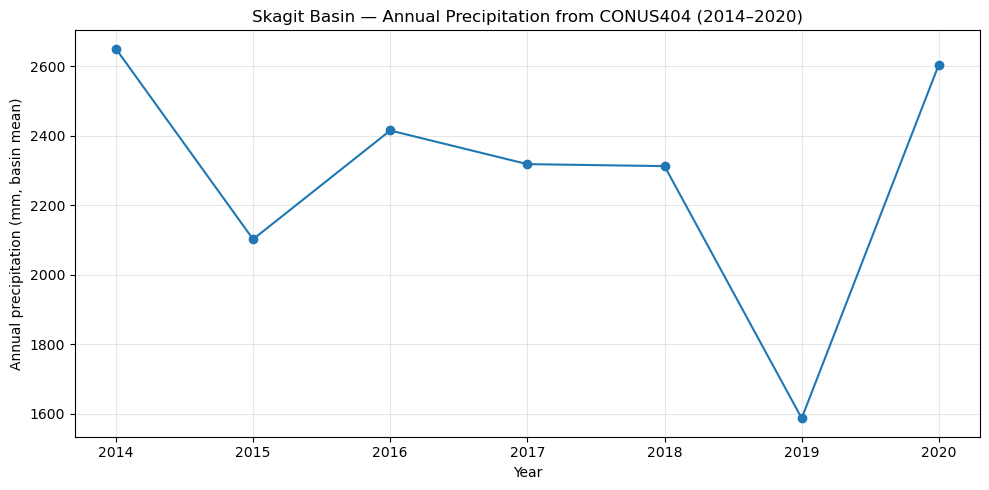

In [15]:
# ================================================
# Skagit Basin — Annual Precipitation from CONUS404
# (2014–2020, using PREC_ACC_NC)
# ================================================

import sys
!{sys.executable} -m pip install -q intake intake-xarray xarray zarr fsspec s3fs geopandas shapely matplotlib

import intake
import xarray as xr
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt

# 1) Open CONUS404 daily dataset
url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
cat = intake.open_catalog(url)
ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
print("✓ Loaded conus404-daily-osn")

# 2) Select precip + time range
var = "PREC_ACC_NC"
if var not in ds.data_vars:
    raise KeyError(f"{var} not found in dataset")

precip = ds[var].sel(time=slice("2014-01-01", "2020-12-31"))
print("✓ Selected PREC_ACC_NC for 2014–2020")

# 3) Load Skagit boundary and build mask (lat/lon are already 2D)
skagit_geo = "../data/GIS/SkagitBoundary.json"  # adjust path if needed
gdf = gpd.read_file(skagit_geo)
geom = gdf.geometry.iloc[0]
print("✓ Loaded Skagit boundary")

lat = ds["lat"]
lon = ds["lon"]
mask_np = shapely.contains_xy(geom, lon.values, lat.values)   # shape (y, x)
mask_da = xr.DataArray(mask_np, dims=("y", "x"))
print("✓ Built Skagit mask")

# 4) Basin-mean daily precip time series
precip_skagit = precip.where(mask_da)
skagit_daily = precip_skagit.mean(dim=("y", "x"))
print("✓ Computed basin-mean daily precip")

# 5) Annual totals (mm per year, basin mean)
skagit_annual = skagit_daily.resample(time="YS").sum()   # YS = year start
years = skagit_annual["time"].dt.year.values
values = skagit_annual.values

print("Annual totals (mm):")
for y, v in zip(years, values):
    print(f"{y}: {float(v):.1f} mm")

# 6) Plot like your example (one line)
plt.figure(figsize=(10, 5))
plt.plot(years, values, marker="o")
plt.title("Skagit Basin — Annual Precipitation from CONUS404 (2014–2020)")
plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm, basin mean)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Total stations with CSV data: 969
                        name network  elevation_m   latitude   longitude  \
code                                                                       
301_CA_SNTL         Adin Mtn  SNOTEL  1886.712036  41.235828 -120.791924   
907_UT_SNTL      Agua Canyon  SNOTEL  2712.719971  37.522171 -112.271179   
916_MT_SNTL       Albro Lake  SNOTEL  2529.840088  45.597229 -111.959023   
1267_AK_SNTL  Alexander Lake  SNOTEL    48.768002  61.749668 -150.889664   
908_WA_SNTL   Alpine Meadows  SNOTEL  1066.800049  47.779572 -121.698471   

                   state           HUC   mgrs  \
code                                            
301_CA_SNTL   California  180200021403  10TFL   
907_UT_SNTL         Utah  160300020301  12SUG   
916_MT_SNTL      Montana  100200050701  12TVR   
1267_AK_SNTL      Alaska  190205051106  05VPJ   
908_WA_SNTL   Washington  171100100501  10TET   

                                mountainRange  beginDate    endDate  csvData  \
code     

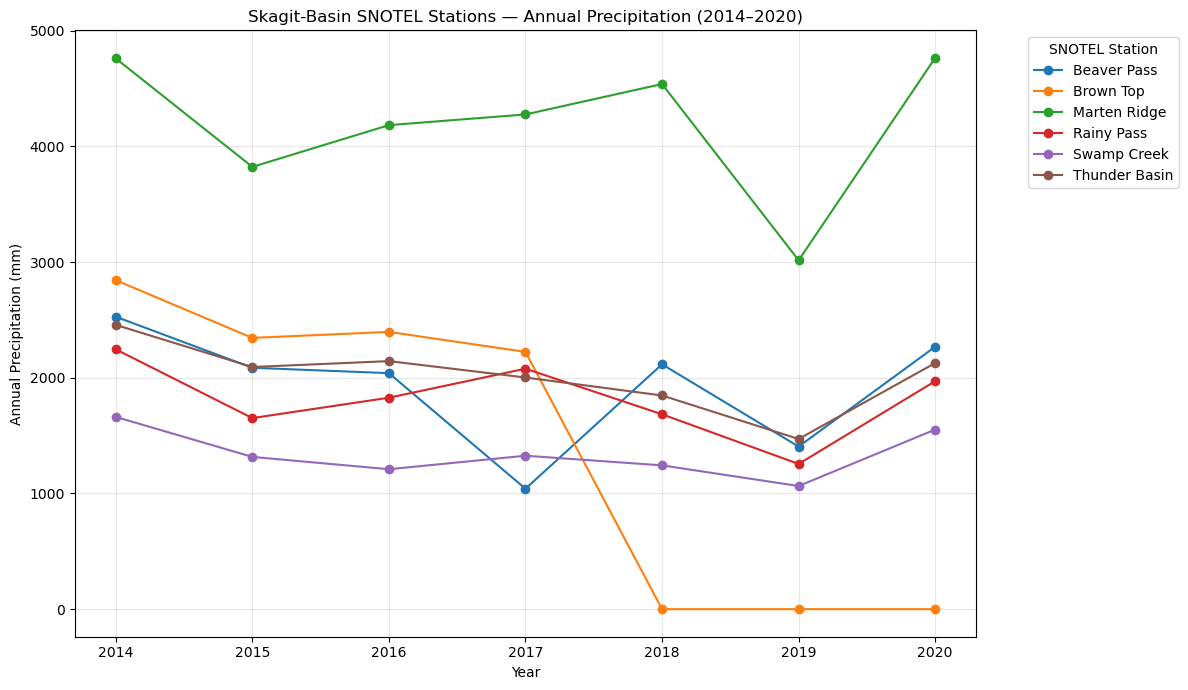


Mean SNOTEL annual precipitation (mm) by year:
year
2014    2749.950000
2015    2219.550000
2016    2300.700000
2017    2158.450000
2018    1905.300000
2019    1368.800000
2020    2114.483333
dtype: float64


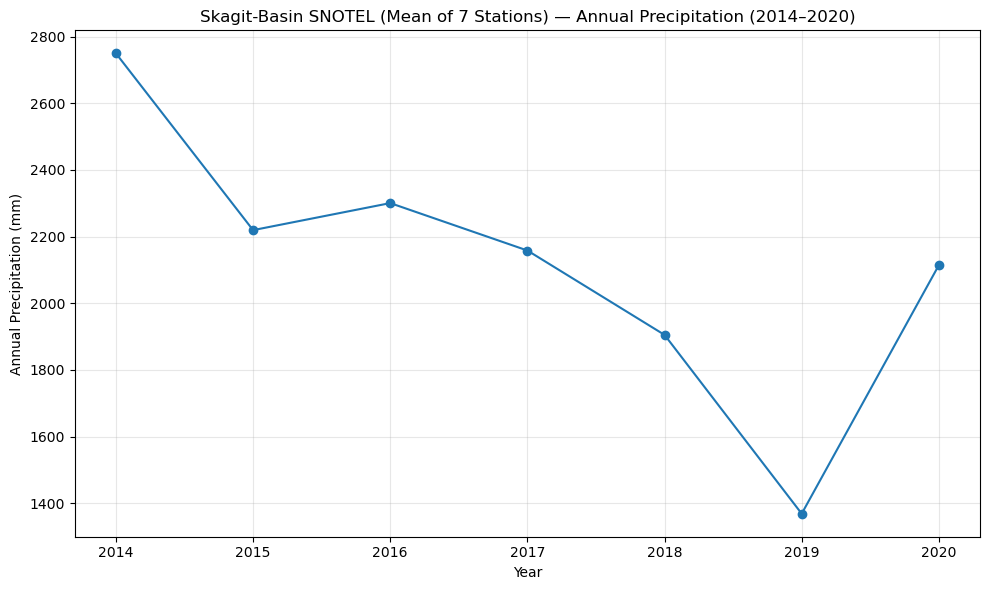

In [16]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

SNOTEL_BASE = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main"

# 1) Load all stations (GeoJSON from GitHub)
stations = (
    gpd.read_file(f"{SNOTEL_BASE}/all_stations.geojson")
    .set_index("code")
)
stations = stations[stations["csvData"] == True]  # only stations with data

print("Total stations with CSV data:", len(stations))
print(stations.head())

# 2) Select the specific 7 stations by name
desired_names = [
    "Brown Top",
    "Rainy Pass",
    "Thunder Basin",
    "Swamp Creek",
    "Beaver Pass",
    "Hozomeen Camp",
    "Marten Ridge",
]

chosen = stations[stations["name"].isin(desired_names)].copy()
print("\nChosen stations:")
print(chosen[["name", "state", "elevation_m"]])

# 3) Loop over each station, read its CSV from GitHub, compute annual precip
rows = []
YEAR_MIN, YEAR_MAX = 2014, 2020

for code, row in chosen.iterrows():
    name = row["name"]
    csv_url = f"{SNOTEL_BASE}/data/{code}.csv"
    print(f"\nLoading {name} ({code}) from {csv_url}")

    df = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)

    # PRCPSA is daily accumulated precipitation [m] in this repo
    if "PRCPSA" not in df.columns:
        print(f"  -> No PRCPSA column for {name}, skipping")
        continue

    # convert m -> mm
    df["PRCPSA_mm"] = df["PRCPSA"] * 1000.0

    # keep 2014–2020 and sum by year
    df_sel = df.loc[f"{YEAR_MIN}-01-01": f"{YEAR_MAX}-12-31"]
    ann = df_sel["PRCPSA_mm"].groupby(df_sel.index.year).sum()

    for year, mm in ann.items():
        rows.append(
            {"station": name, "year": int(year), "mm": float(mm)}
        )

# 4) Build DataFrame and pivot for plotting
annual_df = pd.DataFrame(rows)
annual_df = annual_df[
    (annual_df["year"] >= YEAR_MIN) & (annual_df["year"] <= YEAR_MAX)
].copy()

print("\nAnnual precipitation table:")
print(annual_df.head())

pivot = annual_df.pivot(index="year", columns="station", values="mm").sort_index()

# 5) Plot, one line per station
plt.figure(figsize=(12, 7))

for station in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[station],
        marker="o",
        label=station,
    )

plt.title("Skagit-Basin SNOTEL Stations — Annual Precipitation (2014–2020)")
plt.xlabel("Year")
plt.ylabel("Annual Precipitation (mm)")
plt.grid(True, alpha=0.3)
plt.legend(title="SNOTEL Station", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# pivot: index = year, columns = station, values = annual precip (mm)
# -------------------------------------------
# 1) Compute mean across all SNOTEL stations for each year
snotel_mean = pivot.mean(axis=1)   # one value per year

print("\nMean SNOTEL annual precipitation (mm) by year:")
print(snotel_mean)

# 2) Plot as a single SNOTEL curve
plt.figure(figsize=(10, 6))
plt.plot(snotel_mean.index, snotel_mean.values, marker="o")
plt.title("Skagit-Basin SNOTEL (Mean of 7 Stations) — Annual Precipitation (2014–2020)")
plt.xlabel("Year")
plt.ylabel("Annual Precipitation (mm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Found 97 SNOTEL zarrs


/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


Using SNOTEL variable: PRECIPITATION
Loaded Skagit boundary
Total stations: 9, in Skagit: 7
Annual shape: (7, 7)
      Brown Top  Rainy Pass  Thunder Basin  Swamp Creek  Beaver Pass  \
2014    2844.80     2247.90        2458.72      1663.70      2529.84   
2015    2346.96     1653.54        2095.50      1318.26      2087.88   
2016       0.00        0.00           0.00         0.00         0.00   
2017    1582.42     1369.06        1496.06      1000.76      1041.40   
2018       0.00     1625.60        1783.08      1198.88      1996.44   
2019       0.00     1005.84        1196.34       883.92      1188.72   
2020       0.00     1973.58        2128.52      1554.48      2270.76   

      Hozomeen Camp  Marten Ridge  
2014            0.0       4762.50  
2015            0.0       3825.24  
2016            0.0          0.00  
2017            0.0       2999.74  
2018            0.0       4198.62  
2019            0.0       2501.90  
2020            0.0       4767.58  


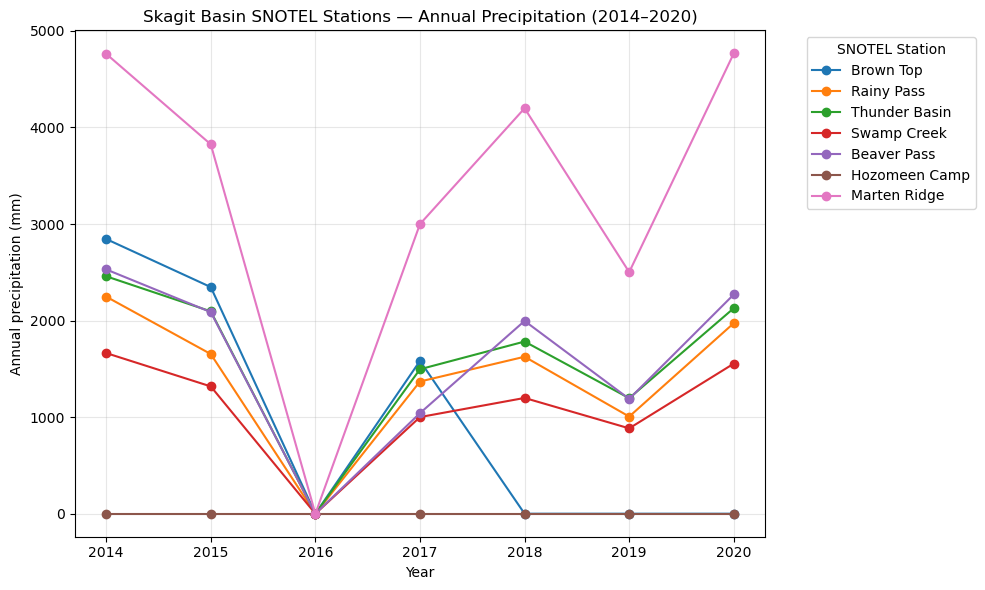

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import shapely.geometry as sgeom

# ---------------- Paths ----------------
BASE = Path("/data0/balaji24/data")
P_SNOTEL_DIR = BASE / "snotel"                   # same as in your script
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2020

# ---------------- Helpers ----------------
def _load_boundary_geom():
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)

    from shapely.geometry import shape, Polygon, LinearRing

    if isinstance(obj, dict) and "type" in obj:
        if obj["type"] == "FeatureCollection":
            return shape(obj["features"][0]["geometry"])
        elif obj["type"] == "Feature":
            return shape(obj["geometry"])
        else:
            return shape(obj)
    elif isinstance(obj, dict) and {"lon","lat"} <= obj.keys():
        pts = list(zip(obj["lon"], obj["lat"]))
        if pts[0] != pts[-1]:
            pts.append(pts[0])
        return Polygon(LinearRing(pts))
    raise ValueError("Unrecognized boundary format")

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# ---------------- Load SNOTEL ----------------
snotel_months = sorted(P_SNOTEL_DIR.glob("**/*.zarr"))
if not snotel_months:
    raise FileNotFoundError("No SNOTEL zarrs found under /data0/balaji24/data/snotel")

print(f"Found {len(snotel_months)} SNOTEL zarrs")
dss = xr.concat(
    [xr.open_zarr(p, consolidated=False) for p in snotel_months],
    dim="time",
    join="outer",
    coords="minimal",
    compat="override",
)

# Pick precip variable
vS = next(
    (v for v in ["PRECIPITATION", "ppt", "prcp", "ACCUMULATED PRECIPITATION", "accum_precip"]
     if v in dss),
    None
)
if vS is None:
    raise KeyError(f"No precip-like var found in SNOTEL dataset. Got: {list(dss.data_vars)}")

da = dss[vS]
print("Using SNOTEL variable:", vS)

# Units → mm
units = str(da.attrs.get("units", "")).lower()
# Heuristic: inches or missing / very small magnitudes
if (not units) or (units in {"inch", "in", "inches"}) or (float(da.max()) <= 10.0):
    da = da * 25.4
    da.attrs["units"] = "mm"

# ---------------- Filter stations inside Skagit ----------------
geom = _load_boundary_geom()
print("Loaded Skagit boundary")

if ("lat" not in dss.coords) or ("lon" not in dss.coords):
    raise KeyError("SNOTEL dataset missing lat/lon coords for stations")

lats = dss["lat"].values
lons = dss["lon"].values

inside_idx = []
for i in range(len(lats)):
    pt = sgeom.Point(float(lons[i]), float(lats[i]))
    inside_idx.append(geom.contains(pt))

inside_idx = np.array(inside_idx)
print(f"Total stations: {len(lats)}, in Skagit: {inside_idx.sum()}")

if inside_idx.sum() == 0:
    raise RuntimeError("No SNOTEL stations found inside Skagit polygon.")

# Subset data to Skagit stations only
site_dim = "site" if "site" in da.dims else da.dims[1]  # crude but works for (time, site)
da_s = da.isel({site_dim: np.where(inside_idx)[0]})

# Try to get a label per station: either a site name or use index
if "site_name" in dss:
    station_labels = dss["site_name"].isel({site_dim: np.where(inside_idx)[0]}).values
else:
    station_labels = np.array([f"site_{i}" for i in np.where(inside_idx)[0]])

# ---------------- Compute annual precip per station ----------------
da_s = ensure_time_sorted_unique(da_s)

# If data are sub-daily / monthly, this still normalizes to daily totals
daily = da_s.resample(time="1D").sum()

# Restrict to study period
daily = daily.sel(time=slice(f"{YEAR_MIN}-01-01", f"{YEAR_MAX}-12-31"))

# Group by year and sum → mm/year per station
annual = daily.groupby("time.year").sum("time")  # dims: year, site
annual = annual.rename({"year": "year"})
print("Annual shape:", annual.shape)

years = annual["year"].values

# Build a DataFrame: rows = years, columns = stations
df_list = []
for j in range(annual.sizes[site_dim]):
    series = annual.isel({site_dim: j})
    vals = series.values
    df_list.append(pd.Series(vals, index=years, name=str(station_labels[j])))

df_annual = pd.concat(df_list, axis=1)
print(df_annual)

# ---------------- Plot: 1 line per SNOTEL station ----------------
plt.figure(figsize=(10, 6))
for col in df_annual.columns:
    plt.plot(df_annual.index, df_annual[col], marker="o", label=col)

plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm)")
plt.title("Skagit Basin SNOTEL Stations — Annual Precipitation (2014–2020)")
plt.grid(True, alpha=0.3)
plt.legend(title="SNOTEL Station", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [5]:
import xarray as xr
import geopandas as gpd
import shapely
import numpy as np
from pathlib import Path

# ----------------------------
# Load PRISM 800m 2014 dataset
# ----------------------------
zarr_path = Path("/data0/balaji24/data/prism_ppt_800m/2014-01-01_2014-12-31_daily_800m_PRISM_data.zarr")
ds = xr.open_zarr(zarr_path)

ppt = ds["ppt"]   # (time, lat, lon), units: mm/day
lat = ds["lat"]
lon = ds["lon"]

# ----------------------------
# Load Skagit Basin boundary
# ----------------------------
boundary_path = "/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json"
gdf = gpd.read_file(boundary_path)
geom = gdf.geometry.iloc[0]   # shapely polygon

# ----------------------------
# Build 2D mask for basin
# ----------------------------
lon2d, lat2d = np.meshgrid(lon.values, lat.values)      # shape (lat, lon)
mask_np = shapely.contains_xy(geom, lon2d, lat2d)       # same shape (lat, lon)
mask_da = xr.DataArray(mask_np, dims=("lat", "lon"))

# ----------------------------
# Compute basin-mean daily precip
# ----------------------------
ppt_masked = ppt.where(mask_da)
daily_mean = ppt_masked.mean(dim=("lat", "lon"))        # mm/day (dask array)

# ----------------------------
# Annual total (mm)
# ----------------------------
annual_2014_mm = float(daily_mean.sum().compute())      # <-- compute() instead of .item()

print("=======================================")
print(" Skagit Basin — PRISM 800m Annual Precip (2014)")
print("=======================================")
print(f" Total Precipitation: {annual_2014_mm:.2f} mm")
print("=======================================")

 Skagit Basin — PRISM 800m Annual Precip (2014)
 Total Precipitation: 2941.22 mm
